In [ ]:
'''9 Classification Techniques
Dataset: Mushroom Dataset
Task:
This dataset includes descriptions of hypothetical mushrooms based on physical characteristics. You are required to classify mushrooms as edible or poisonous.
a. Apply label encoding for categorical variables.
b. Split dataset into training and test sets.
c. Apply Naive Bayes classifier and Decision Tree models.
d. Evaluate using accuracy and confusion matrix.
e. Perform cross-validation for model verification.'''

'9 Classification Techniques\nDataset: Mushroom Dataset\nTask:\nThis dataset includes descriptions of hypothetical mushrooms based on physical characteristics. You are required to classify mushrooms as edible or poisonous.\na. Apply label encoding for categorical variables.\nb. Split dataset into training and test sets.\nc. Apply Naive Bayes classifier and Decision Tree models.\nd. Evaluate using accuracy and confusion matrix.\ne. Perform cross-validation for model verification.'

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("Navy Bays_Mushroom Dataset.csv")


In [ ]:
df.head(5)

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,5,2,4,1,6,1,0,1,4,0,...,7,7,0,2,1,4,2,3,5,1
1,5,2,9,1,0,1,0,0,4,0,...,7,7,0,2,1,4,3,2,1,0
2,0,2,8,1,3,1,0,0,5,0,...,7,7,0,2,1,4,3,2,3,0
3,5,3,8,1,6,1,0,1,5,0,...,7,7,0,2,1,4,2,3,5,1
4,5,2,3,0,5,1,1,0,4,1,...,7,7,0,2,1,0,3,0,1,0


In [ ]:
X = df.drop("poisonous", axis=1)  # Features
y = df["poisonous"]               # Target: edible or poisonous


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

x_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model_gb = GaussianNB()
model_gb.fit(x_train, y_train)

GaussianNB()

In [ ]:
y_pred_gb = model_gb.predict(X_test)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       843
           1       0.93      0.92      0.93       782

    accuracy                           0.93      1625
   macro avg       0.93      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625


ROC-AUC Score: 0.9284221192732083


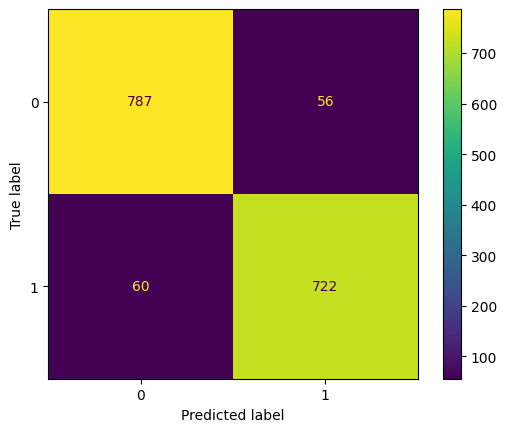

In [ ]:
from sklearn.metrics import classification_report,roc_auc_score,ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)
print(classification_report(y_test, y_pred_gb))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_gb))

In [ ]:
cv_nb = cross_val_score(model_gb, X, y, cv=5)
print("Naive Bayes 5-Fold CV Accuracy:", cv_nb.mean())

Naive Bayes 5-Fold CV Accuracy: 0.7184608563849941


In [ ]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)


# Predict



In [ ]:
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


ROC-AUC Score: 1.0


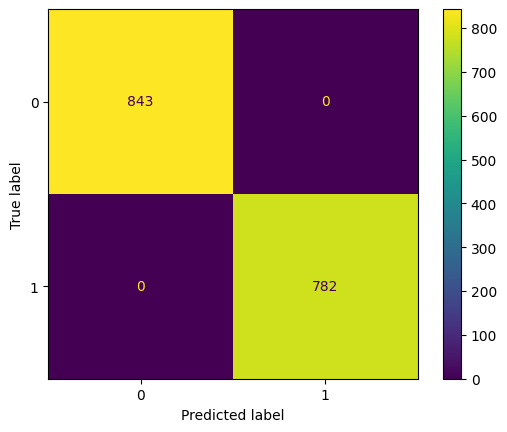

In [ ]:
from sklearn.metrics import classification_report,roc_auc_score,ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
print(classification_report(y_test, y_pred_dt))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_dt))

In [ ]:
cv_dt = cross_val_score(dt_model, X, y, cv=5)
print("Decision Tree 5-Fold CV Accuracy:", cv_dt.mean())


Decision Tree 5-Fold CV Accuracy: 0.9524832133383858


In [ ]:
# Example: assume X_encoded.columns has 22 columns
new_mushroom = [val for val in range(22)]  # replace with correct encoded values

ad=model_gb.predict([new_mushroom])
print(ad)


[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


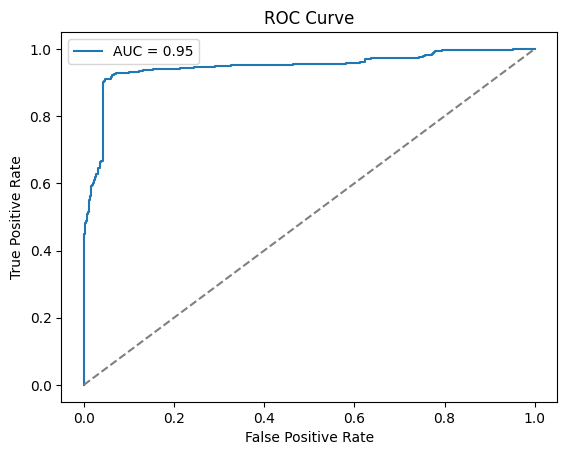

In [ ]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for positive class
y_prob = model_gb.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], '--', color='gray')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()